#                             **Paisabazaar Bank Fraud Analysis**

###**Business Context**


Paisabazaar is a financial services company that assists customers in finding and applying for various banking and credit products. An integral part of their service is assessing the creditworthiness of individuals, which is crucial for both loan approval and risk management. The credit score of a person is a significant metric used by financial institutions to determine the likelihood that an individual will repay their loans or credit balances. Accurate classification of **credit scores can help Paisabazaar enhance their credit assessment processes,** **reduce the risk of loan defaults,** and **offer personalized financial advice to their customers**.

In this context, analyzing and classifying credit scores based on customer data can improve decision-making processes and contribute to **better financial product recommendations.** This case study aims to **develop a model that predicts the credit score** of individuals based on various features, such as income, credit card usage, and payment behavior.

## **Problem statement**

How Paisabazzar can optimize credit assessment process by  utilizing **credit score** metrics to **mitigate the risk of loan defaults**, and **offer personalized financial advice** to their customers.

This case study aims to predicts the **credit score** of individuals based on various features, such as income, credit card usage, and payment behavior.

###**Business Objective/Goal**

Paisabazaar want to enhance the credit assessment processes to reduce the risk of loan defaults and offer personalized financial advice to their customers.

**What exactly we have to do in analysis and what we are looing**

We have to analyzing or find out how credit score of an individuals based on various features, such as income, credit card usage, and payment behavior can help to make decision for mitigating the risk of loan defaults and offer personalized financial advice.

**Loading Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go
import plotly.express as px

In [ ]:
pd.set_option('Display.max_columns', None)
pd.set_option('Display.max_rows', 500)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/paisabazzar_dataset.csv')

**Inspecting Data**

In [ ]:
data.shape

(100000, 28)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'debt_to_income_ratio', 'Credit_Score_Numeric'],
      dtype='object')

In [ ]:
data.head(50)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.465380,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.465380,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.465380,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.465380,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.465380,High_spent_Medium_value_payments,341.489231,Good
5,5639,3392,6,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8.0,4.0,9.27,4.0,Good,809.98,27.262259,270.0,No,49.574949,21.465380,High_spent_Medium_value_payments,340.479212,Good
6,5640,3392,7,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,8.0,11.27,4.0,Good,809.98,22.537593,271.0,No,49.574949,21.465380,Low_spent_Small_value_payments,244.565317,Good
7,5641,3392,8,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,6.0,11.27,4.0,Good,809.98,23.933795,272.0,No,49.574949,21.465380,High_spent_Medium_value_payments,358.124168,Standard
8,5646,8625,1,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,4.0,5.42,2.0,Good,605.03,24.464031,319.0,No,18.816215,39.684018,Low_spent_Small_value_payments,470.690627,Standard
9,5647,8625,2,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,7.0,1.0,7.42,2.0,Good,605.03,38.550848,320.0,No,18.816215,39.684018,High_spent_Large_value_payments,484.591214,Good


In [ ]:
data.tail(50)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99950,155556,20915,7,Ryana,33.0,837859800.0,Media_Manager,59146.36,4908.863333,3.0,6.0,6.0,1.0,Personal Loan,8.0,6.0,6.68,5.0,Good,418.03,38.199635,247.0,No,26.778419,77.794586,Low_spent_Small_value_payments,251.731594,Standard
99951,155557,20915,8,Ryana,33.0,837859800.0,Media_Manager,59146.36,4908.863333,3.0,6.0,6.0,1.0,Personal Loan,8.0,6.0,6.68,5.0,Good,418.03,27.682186,248.0,No,26.778419,77.794586,Low_spent_Large_value_payments,389.488483,Standard
99952,155562,8324,1,Ryanl,20.0,253727758.0,Architect,38321.39,3354.449167,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,4.0,1.59,3.0,Good,678.57,35.123923,203.0,No,114.271146,26.701680,High_spent_Small_value_payments,349.184777,Poor
99953,155563,8324,2,Ryanl,21.0,253727758.0,Architect,38321.39,3354.449167,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,7.0,1.59,3.0,Good,678.57,25.251095,204.0,No,114.271146,26.701680,High_spent_Large_value_payments,381.935842,Poor
99954,155564,8324,3,Ryanl,21.0,253727758.0,Architect,38321.39,3354.449167,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,10.0,1.59,3.0,Good,678.57,27.013535,205.0,No,114.271146,26.701680,High_spent_Medium_value_payments,381.405249,Poor
99955,155565,8324,4,Ryanl,21.0,253727758.0,Architect,38321.39,3106.647859,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,7.0,1.59,3.0,Good,678.57,35.455305,206.0,No,362.072453,26.701680,Low_spent_Large_value_payments,197.460577,Standard
99956,155566,8324,5,Ryanl,21.0,253727758.0,Architect,38321.39,3106.647859,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,7.0,1.59,3.0,Good,678.57,39.802619,207.0,No,362.072453,26.701680,Low_spent_Small_value_payments,106.375283,Standard
99957,155567,8324,6,Ryanl,21.0,253727758.0,Architect,38321.39,3106.647859,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,7.0,1.59,3.0,Good,678.57,37.367063,208.0,No,362.072453,26.701680,High_spent_Large_value_payments,434.472091,Standard
99958,155568,8324,7,Ryanl,21.0,253727758.0,Architect,38321.39,3106.647859,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",11.0,10.0,1.59,3.0,Good,678.57,28.360351,209.0,No,362.072453,26.701680,Low_spent_Large_value_payments,309.106120,Standard
99959,155569,8324,8,Ryanl,21.0,253727758.0,Architect,38321.39,3106.647859,4.0,4.0,3.0,4.0,"Student Loan, Debt Consolidation Loan, Student...",6.0,7.0,1.59,6.0,Good,678.57,28.951691,210.0,No,362.072453,26.701680,Low_spent_Medium_value_payments,242.038135,Standard


In [ ]:
data.describe(include = 'float')

,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


###**Understanding The Structure of data**

As we can see that in our data, one customer_id have multiple row, if we  subset the data then found that rows are duplicated.
so How we gonna to deal with this data

1. **Delete:** the very first solution that we can delete those duplicate rows but we will loose plenty of data almost 90%.

2. **groupby:** we can do groupby data on the basis of customer_id and keep row last but this also comprassed our data of each customer_id, one customer_id have multiple rows almost 6 to 8, so we loose them.

3. **Don't change Keep it as it as :** We are not going to delete or groupby our data because we have to understand why these multiple row are in our data. so after Understanding the data, i examine Month column and came to the conclusion that all multiple row of unique customer_id have the record of each month. all multiple entrie show us that the behaviour of each customer in different month.

so this tis good for analysis because we are not going to analysis on the base of count of customer but we are going to make analysis in the respect of how credit score influenced by each features (columns) or in another word how different metric leave impact over credit score.

### **Data Prepration**

Dropping Some Irrelevant Columns so less space consumed and operation will be faster

In [ ]:
data.drop(columns = ['Name','SSN'], inplace = True, axis = 1)       # These columns are not useful for anlysis

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Age                       100000 non-null  float64
 4   Occupation                100000 non-null  object 
 5   Annual_Income             100000 non-null  float64
 6   Monthly_Inhand_Salary     100000 non-null  float64
 7   Num_Bank_Accounts         100000 non-null  float64
 8   Num_Credit_Card           100000 non-null  float64
 9   Interest_Rate             100000 non-null  float64
 10  Num_of_Loan               100000 non-null  float64
 11  Type_of_Loan              100000 non-null  object 
 12  Delay_from_due_date       100000 non-null  float64
 13  Num_of_Delayed_Payment    100000 non-null  fl

Changing Data Type

In [ ]:
# Age column is in float which is not making any sense.

data ['Age'] = data ['Age'].astype(int)    # Changing Age column from float to int

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Age                       100000 non-null  int64  
 4   Occupation                100000 non-null  object 
 5   Annual_Income             100000 non-null  float64
 6   Monthly_Inhand_Salary     100000 non-null  float64
 7   Num_Bank_Accounts         100000 non-null  float64
 8   Num_Credit_Card           100000 non-null  float64
 9   Interest_Rate             100000 non-null  float64
 10  Num_of_Loan               100000 non-null  float64
 11  Type_of_Loan              100000 non-null  object 
 12  Delay_from_due_date       100000 non-null  float64
 13  Num_of_Delayed_Payment    100000 non-null  fl

In [ ]:
data['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


The Major column Credit Score have value in object i am going to convert into Category, So i can Compare with other features/Variable.

In [ ]:
# Converting text-based fields into ordered  categorical datatypes so charts automatically display bars
data['Credit_Score'] =  pd.Categorical(data['Credit_Score'], categories=['Poor', 'Standard', 'Good'], ordered=True)

In [ ]:
data.head()

,ID,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### **Data Cleaning**

#### **Removing Duplicates**

In [ ]:
# Checking How Much duplicates row are in the data

data.duplicated().sum()                 # There is no Duplicates Value found in the Data

np.int64(0)

In [ ]:
data.drop_duplicates(inplace = True)   # Dropping Duplicates in Case

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   ID                        100000 non-null  int64   
 1   Customer_ID               100000 non-null  int64   
 2   Month                     100000 non-null  int64   
 3   Age                       100000 non-null  int64   
 4   Occupation                100000 non-null  object  
 5   Annual_Income             100000 non-null  float64 
 6   Monthly_Inhand_Salary     100000 non-null  float64 
 7   Num_Bank_Accounts         100000 non-null  float64 
 8   Num_Credit_Card           100000 non-null  float64 
 9   Interest_Rate             100000 non-null  float64 
 10  Num_of_Loan               100000 non-null  float64 
 11  Type_of_Loan              100000 non-null  object  
 12  Delay_from_due_date       100000 non-null  float64 
 13  Num_of_Delayed_Payment    1000

In [ ]:
# Dropping Duplicate in subset to  Finds instances where the system generated two rows for the same customer profile.
# Including Outstanding_Debt column confirms  that the actual financial data is identical.

data.duplicated(subset=['Customer_ID', 'Month']).sum()
data.drop_duplicates(subset = ['Customer_ID', 'Month', 'Outstanding_Debt', 'Monthly_Balance', 'Total_EMI_per_month'], inplace = True, keep = 'last')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

### **Handling Missing and Null Values**


In [ ]:
# Finding the missing value in case hidden null and filling the space with words like NULL, N/A, UNKNOWN

for i in ['missing', 'null', 'miss', 'Not available', 'Unknown', 'N/A', "Not Applicable"]:
  data.replace({i: np.nan},inplace= True)


In [ ]:
# Checking Percentage of Null Value

data.isna().mean()*100                                       # There are no Null Values

,0
ID,0.0
Customer_ID,0.0
Month,0.0
Name,0.0
Age,0.0
SSN,0.0
Occupation,0.0
Annual_Income,0.0
Monthly_Inhand_Salary,0.0
Num_Bank_Accounts,0.0


In [ ]:
# dropping Null Values

data.dropna(inplace = True)   # Dropping Null in Case

### **Treating Outliers**

Looking Outliers in data

In [ ]:
data.describe(include= 'object')

,Occupation,Type_of_Loan,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
count,100000,100000,100000,100000,100000
unique,15,6261,3,3,6
top,Lawyer,No Data,Standard,Yes,Low_spent_Small_value_payments
freq,7096,11408,45848,52326,28616


In [ ]:
data.describe(include= 'int')

,ID,Customer_ID,Month,Age
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340
std,43301.486619,14340.543051,2.291299,10.764812
min,5634.000000,1006.000000,1.000000,14.000000
25%,43132.750000,13664.500000,2.750000,24.000000
50%,80631.500000,25777.000000,4.500000,33.000000
75%,118130.250000,38385.000000,6.250000,42.000000
max,155629.000000,50999.000000,8.000000,56.000000


In [ ]:
data.describe(include= 'float')

,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,179987.280000,15204.633333,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [ ]:
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Age', 'Occupation', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'debt_to_income_ratio'],
      dtype='object')

Data With heavy outliers

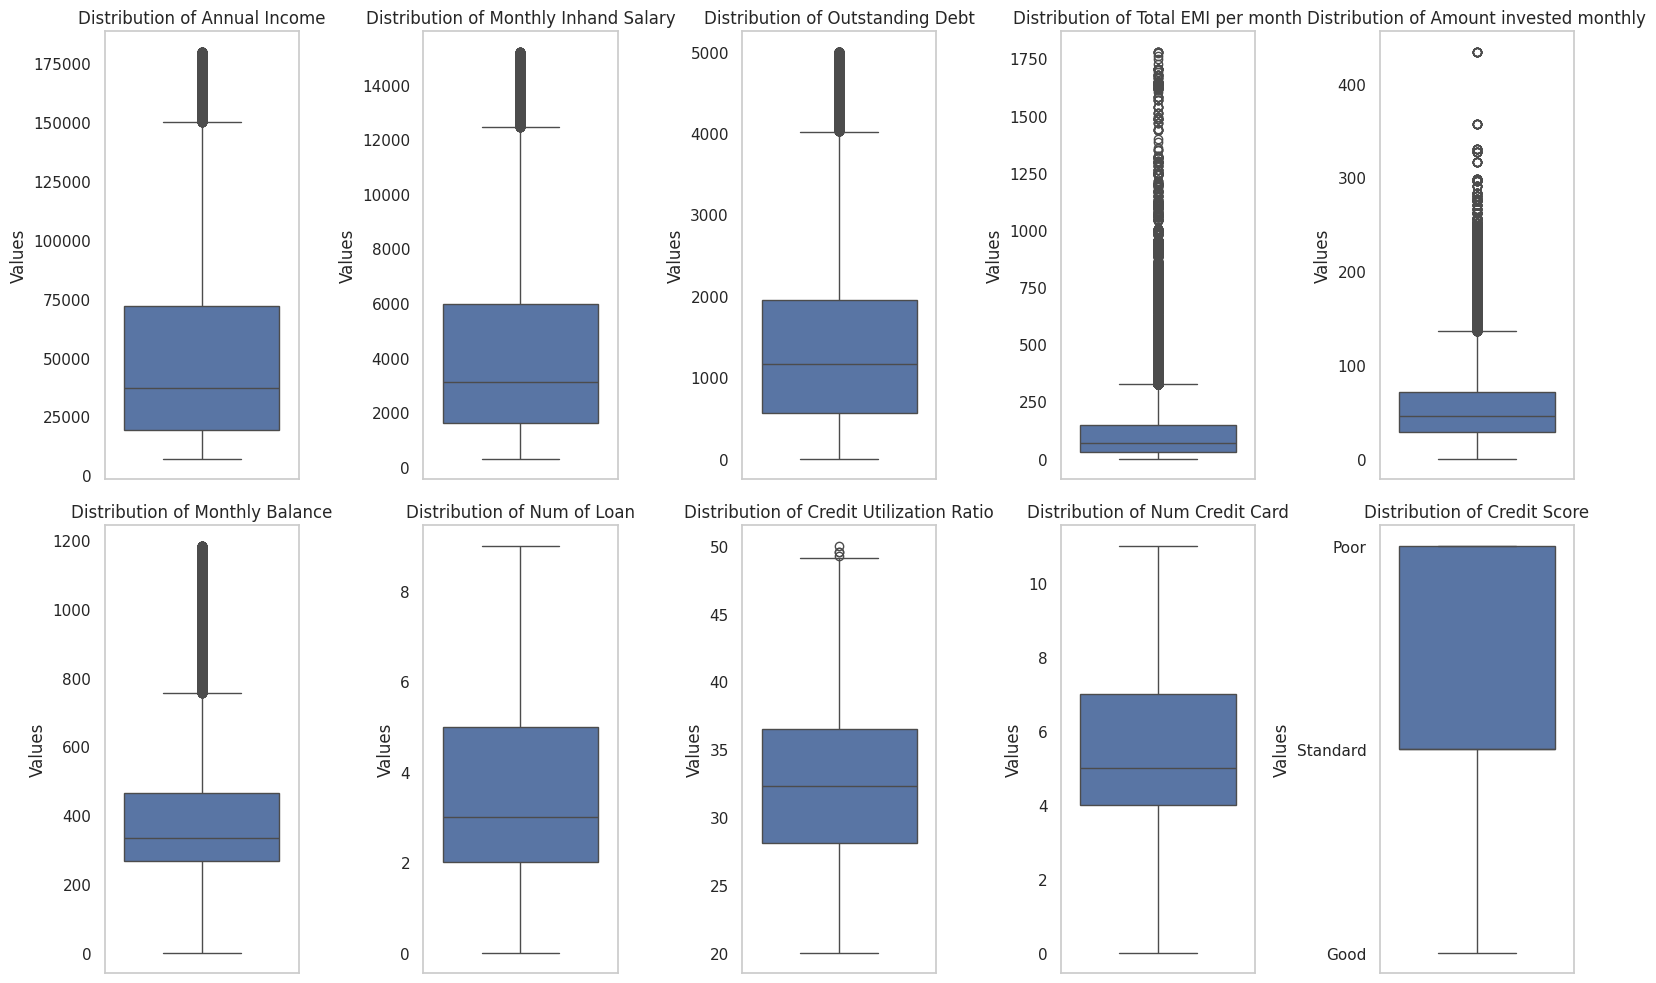

In [ ]:
# outliers in column  --> Annual_Income
# outliers in column  --> Monthly_Inhand_salary
# outliers in column  --> Outstanding_Debt
# outliers in column  --> Total_EMI_per_month
# outliers in column  --> Amount_invested_monthly
# outliers in column  --> Monthly_Balance
# outliers in column  --> Credit_Utilization_Ratio


# Inspecting Oulier through visulazation

columns = ['Annual_Income', 'Monthly_Inhand_Salary','Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Loan', 'Credit_Utilization_Ratio', 'Num_Credit_Card', 'Credit_Score'  ]


fig, axes = plt.subplots(2, 5, figsize=(16, 10))

axes = axes.flatten()

for col, ax in zip(columns, axes):
  sns.boxplot(data=data, y=col, ax=ax)
  ax.set_title(f"Distribution of {col.replace('_', ' ')}")
  ax.set_ylabel("Values")
  ax.set_xlabel("")
  ax.grid(False)

plt.tight_layout()
plt.show()




Capping Outlier

In [ ]:
# Loop through each column to cap outliers
columns = ['Annual_Income', 'Monthly_Inhand_Salary','Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_Utilization_Ratio', ]
for col in columns:

    q1 = data[col].quantile(0.25)             # Calculation of quartiles and IQR
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1


    lower_bound = q1 - 1.5 * iqr               # Define the upper and lower whiskers/bounds
    upper_bound = q3 + 1.5 * iqr

    # Cap the values using numpy.clip
    import numpy as np

    data[col] = np.clip(data[col], lower_bound, upper_bound)


Same Data After Capping Outliers


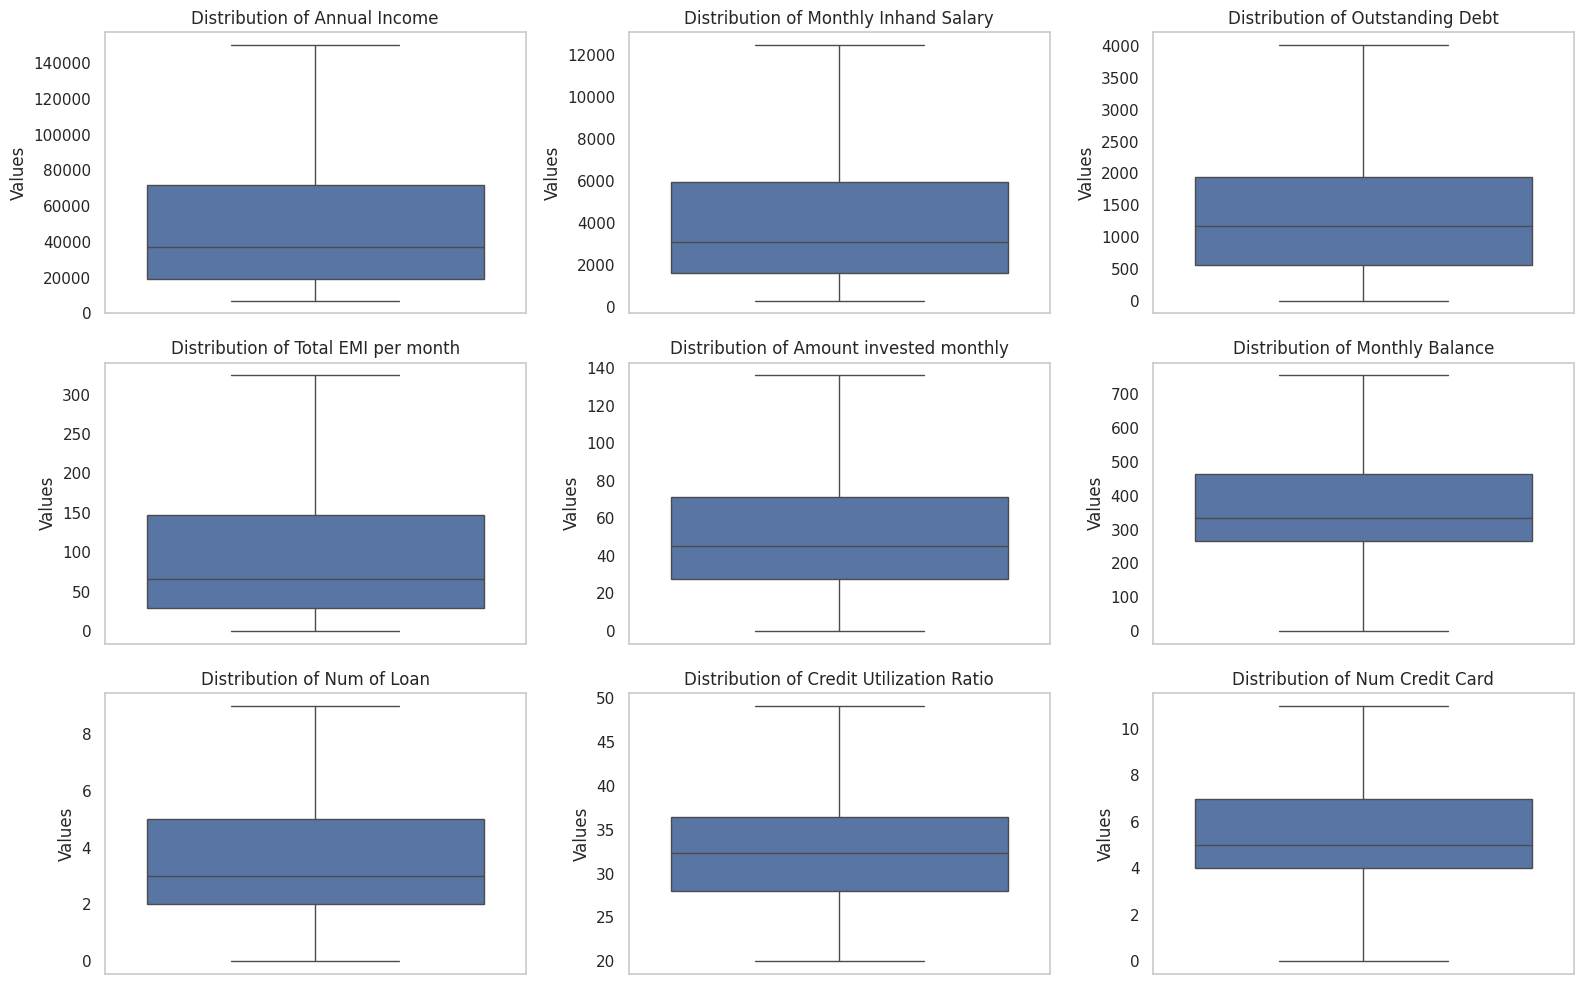

In [ ]:
# Inspecting Oulier through visulazation
columns = ['Annual_Income', 'Monthly_Inhand_Salary','Outstanding_Debt', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Loan', 'Credit_Utilization_Ratio', 'Num_Credit_Card' ]


fig, axes = plt.subplots(3, 3, figsize=(16, 10))

axes = axes.flatten()

for col, ax in zip(columns, axes):
    sns.boxplot(data=data, y=col, ax=ax )
    ax.set_title(f"Distribution of {col.replace('_', ' ')}")
    ax.set_ylabel("Values")
    ax.set_xlabel("")
    ax.grid(False)

plt.tight_layout()
plt.show()

### **Variable Engineering**

In [ ]:
data.head()

,ID,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


**Debt to Income (DTI) Ratio:**

Dividing column Total_EMI_per_month by column Monthly_Inhand_Salary to track immediate affordability.


In [ ]:
# Outstanding_Debt by Annual_Income

data['debt_to_income_ratio'] = round((data['Outstanding_Debt'] / data['Annual_Income']),2)


In [ ]:
data.head()

,ID,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,debt_to_income_ratio
0,5634,3392,1,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good,0.04
1,5635,3392,2,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good,0.04
2,5636,3392,3,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good,0.04
3,5637,3392,4,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good,0.04
4,5638,3392,5,23,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good,0.04


#**Analysis**  

### **Visualizing how other features influence the credit score metric to identify key risk areas.**

###**1. Credit Score Vs Debt to Income Ratio (DTI) Distribution**

In [ ]:
# THE CONTINUOUS PLOTLY CHART
# ----------------------------------------------------
fig = px.histogram(
    data,
    x='debt_to_income_ratio',
    color='Credit_Score',
    marginal='box', # Adds an automatic box plot on top of the histogram peaks
    title='Risk Analytics: Continuous Debt-to-Income (DTI) Ratio Distribution',
    labels={'debt_to_income_ratio': 'Continuous Debt-to-Income (DTI) Ratio', 'count': 'Number of Customers', 'Credit_Score': 'Credit Status'},
    color_discrete_map={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'},
    opacity=0.7,
    nbins=30 # Numbers of financial data bars
)

# Customizing layout for cleaner presentation
fig.update_layout(
    xaxis_title="Continuous DTI Metric Value (Total EMI / Net Income)",
    yaxis_title="Volume of Customers",
    legend_title="Credit Score",
    font=dict(family="Arial", size=12),
    barmode='overlay' # Overlays transparent curves to see the direct overlapping ranges
)

fig.show()

**Key Insights & Risk Analysis**


####**🔍 Observations:**

**Low DTI Correlates with Strong Credit Performance:**
   The heavy concentration of data between **0.0 and 0.1 DTI** shows that the vast majority of the customer base maintains low debt relative to income. The green distribution highlights that customers with **"Good" credit scores** are tightly packed within this safe zone, demonstrating disciplined borrowing.


**The Critical Risk Boundary (> 0.3 DTI):**
   The **"Poor" (light Red)** credit score distribution is heavily and long tail dominates the graph because it spreads far to one side Any borrower crossing the **0.3 DTI threshold** represents a highly critical risk area, where stable profiles virtually disappear and default risk escalates exponentially.


####**📊 Interpretations:**

**The Safe Zone (Low DTI):** The heavy concentration of data on the left side of the histogram shows that the majority of customers have a low DTI ratio (between 0.0 and 0.1).

**Good Credit Score:** Looking at the green box plot (top row), customers with Good credit scores are tightly clustered at the lowest DTI levels. Their distribution is highly disciplined, rarely crossing past a DTI of 0.1.

**Standard Credit Score Behavior:** The orange box plot shows customers with a Standard credit score. They generally hold slightly higher DTI ratios, stretching safely up to around 0.25 before hitting outlier territory.

**The High Risk Area (Poor Credit Scores):** The light red box plot representing Poor credit scores are most critical risk. It is extremely long, showing a wide spread that stretches far into high DTI ratios. Customers with DTI ratios above 0.3 are almost entirely associated with poor credit scores.

####**🚀 Implications:**

Paisabazzar should set A **Debt-to-Income ratio of 0.3**  as a hard regulatory threshold or risk filter for initial lending decisions to protect portfolio quality.


##**2. Income vs. Credit Score Analysis**

#### Finding relation between Income over Credit Score

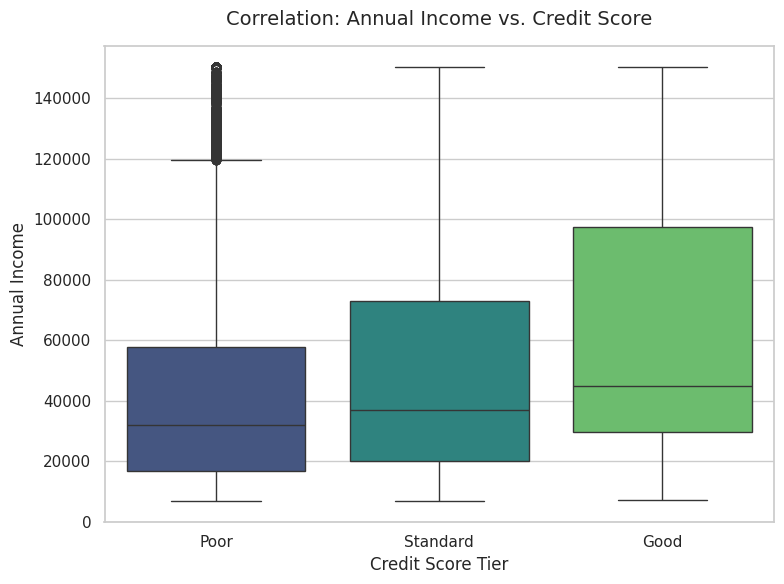

In [ ]:
# Boxplot shows the median, ranges, and outliers clearly and any relation

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='Credit_Score', y='Annual_Income', palette='viridis', hue='Credit_Score', legend=False)

plt.title('Correlation: Annual Income vs. Credit Score', fontsize=14, pad=15)
plt.xlabel('Credit Score Tier', fontsize=12)
plt.ylabel('Annual Income', fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()

#### 🔍 **Observations:**

**The Box (Interquartile Range):** The colored box for "Good" scores will be positioned much higher on the Income than the "Poor" box, visually proving the correlation.

**The Median:** The horizontal line inside the "Good" box represents the median income for that group, which will be distinctively higher. The highest median income (around 45k-50k) and a much higher upper quartile, showing that high-income earners are strongly represented in top credit brackets.

**The Risk Anomaly (High-Income Outliers):** There is a distinct, thick black line of outliers in the "Poor" category extending from roughly 120k to 140k+. This indicates a highly specific, dense cluster of high-earning individuals who nonetheless possess a poor credit score.

**Overlap:** Minimal overlap between the "Poor" and "Good" boxes indicates a strong ability for income to serve as a predictor for creditworthiness.

#### 📊 **Interpretations:**

This chart visualizes the relationship between a customer's Annual Income and their assigned Credit Score Tier (Poor, Standard, Good). It highlights how earning capacity correlates with credit worthiness and uncovers a unique anomaly in the lower-tier segment.  

There is a clear upward trend in income across the tiers. The "Good" tier (green) possesses the highest median income round 45k to 50k and a much higher upper quartile, showing that high-income earners are strongly represented in top credit brackets

🚀 **Implications:**

Paisabazzar should take a note that high-income individual with a poor credit score represents a high-risk anomaly. They have the capacity to pay but fail to do so, making them more dangerous than low-income individuals who simply lack financial capacity.

Paisabazzar should not rely too heavily on raw annual income alone. The presence of this high-income "Poor" cluster justifies the inclusion of multi-variable metrics (like the Debt-to-Income ratio discussed earlier) to filter out deceptive high-earning applicants.

### **3. Analysing Credit utilization ratio impact on credit scores compared to the total number of loan taken?**

Credit utilization ratio impact on credit scores

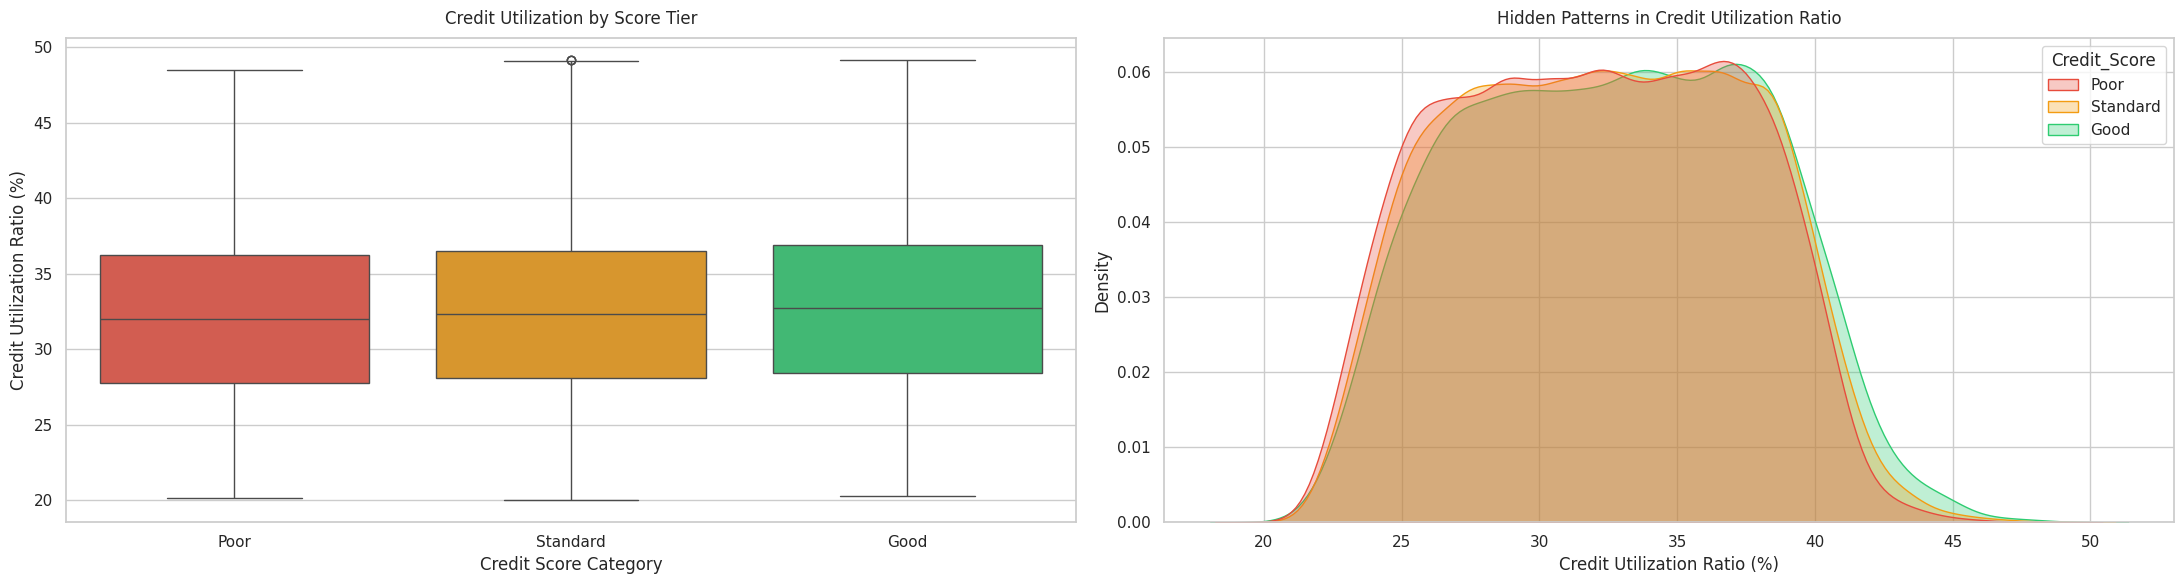

In [ ]:

# Set overall clean theme
sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(1, 2, figsize=(22, 6)) # 1. Initialize a 1 row by 3 column grid of subplots

# selecting matching color palette for consistent visualization
score_palette = {"Poor": "#e74c3c", "Standard": "#f39c12", "Good": "#2ecc71"}

# --- CHART 1 (Left): Credit Utilization Boxplot ---
sns.boxplot(data=data, x="Credit_Score", y="Credit_Utilization_Ratio", hue="Credit_Score", legend=False, ax=axes[0], palette=score_palette)

axes[0].set_title("Credit Utilization by Score Tier", fontsize=12, pad=10)
axes[0].set_xlabel("Credit Score Category")
axes[0].set_ylabel("Credit Utilization Ratio (%)")

# --- CHART 2 (Middle): Credit Utilization Density Plot ---
sns.kdeplot(data=data, x="Credit_Utilization_Ratio", hue="Credit_Score", fill=True, palette=score_palette, alpha=0.3,
    common_norm=False, ax=axes[1] )

axes[1].set_title("Hidden Patterns in Credit Utilization Ratio", fontsize=12, pad=10)
axes[1].set_xlabel("Credit Utilization Ratio (%)")
axes[1].set_ylabel("Density")

plt.tight_layout()  # adjusting space to prevent overlap
plt.show()


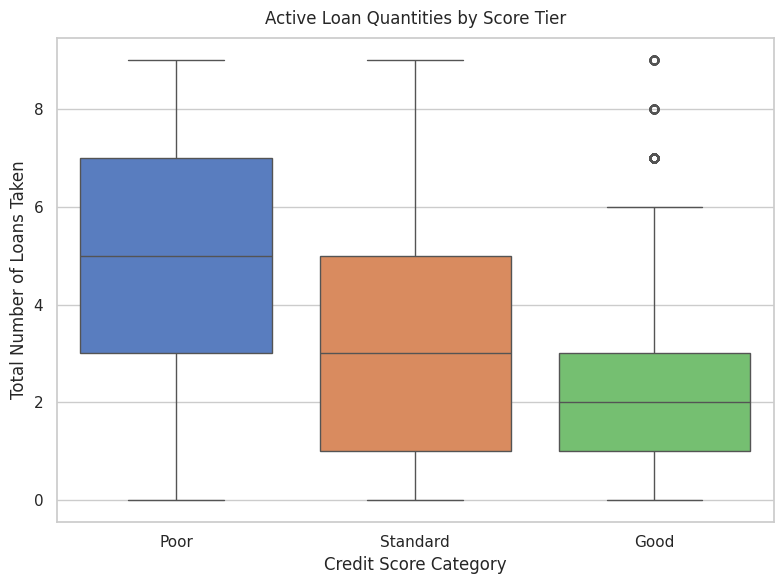

In [ ]:
# ---  Active Loan Quantities Boxplot ---

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x="Credit_Score", y="Num_of_Loan", hue="Credit_Score", legend=False, palette="muted")

plt.title("Active Loan Quantities by Score Tier", fontsize=12, pad=10)
plt.xlabel("Credit Score Category")
plt.ylabel("Total Number of Loans Taken")


plt.tight_layout()  # adjusting space to prevent overlap
plt.show()


#### **🔍 Observations:**

**Identical Distributions:** Both the side-by-side boxplot and the density curve perfectly overlap. The distribution shape, range (20% to 50%), and median are completely identical across Poor, Standard, and Good categories.

**Zero Separation:** The overlapping peaks in the middle chart prove that knowing a customer's credit utilization gives exactly zero clues about their actual credit tier.

**Clear Tier Separation:** Unlike credit utilization, this feature shows distinct behavioral patterns. There is a visible step-down pattern in loan quantities as credit scores improve.

**Higher Debt Volume in Lower Tiers:** The "Poor" tier (blue) holds the highest concentration of active loans, with a median of 5 loans and an upper quartile stretching to 7.

#### **📊 Interpretations:**

The visualization looks weird because the underlying data has a uniform or perfectly normal distribution across all credit categories.In the real world, higher credit utilization strongly correlates with lower credit scores.

Total number of Active Loan's "Good" tier (green) is tightly managed, maintaining a median of only 2 to 3 active loans.

#### **🚀 Implications:**

Credit Utilization Ratio metric is highly useful for risk profiling. A higher volume of open active loans directly correlates with credit deterioration.
Paisabazzar should use other metric to itdentify risk factor.

Paisabazzar restrict or flag applicants with > 4 active loans serves as an effective risk filter. applicants with > 4 active loans serves as an effective risk filter.

#### **4. Analyzing whether owning more credit cards correlates with a higher credit score, provided that the credit utilization ratio remains well-managed**

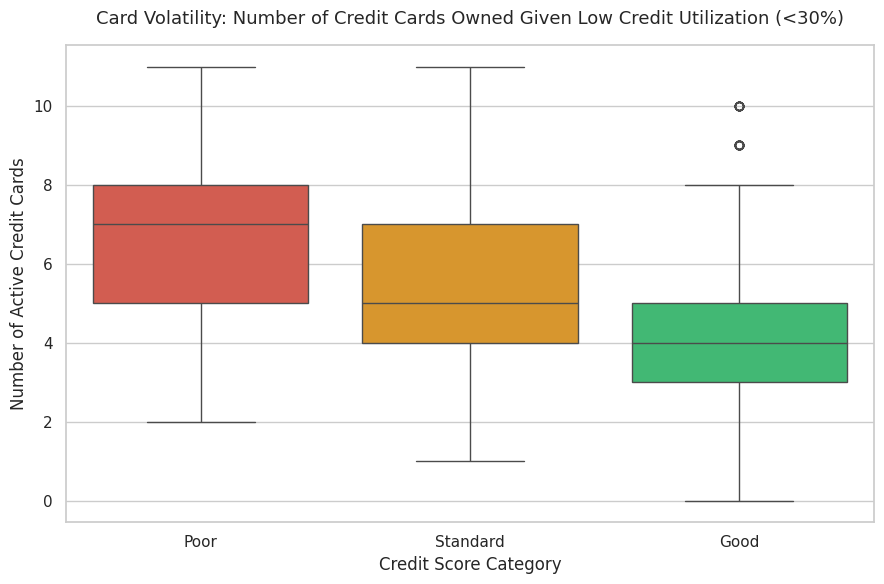

In [ ]:
well_managed_df = data[data['Credit_Utilization_Ratio'] < 30]

plt.figure(figsize=(9, 6))

# Boxplot comparing credit card counts across scores under the utilization filter
sns.boxplot(data=well_managed_df, x='Credit_Score', y='Num_Credit_Card', hue='Credit_Score', legend=False
    palette={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'})



plt.title('Card Volatility: Number of Credit Cards Owned Given Low Credit Utilization (<30%)', fontsize=13, pad=15)
plt.xlabel('Credit Score Category')
plt.ylabel('Number of Active Credit Cards')
plt.tight_layout()
plt.show()


#### **🔍 Observations:**

**Inverse Relationship with Tiers:**

There is a clear, step-down trend in card ownership as credit quality improves.

**The "Poor" Tier Pattern (Red):** This group has the highest median number of credit cards (7 active cards), with the bulk of the data ranging between 5 and 8 cards.

**The "Standard" Tier Pattern (Yellow):**This group occupies the middle ground with a lower median of 5 active cards.

**The "Good" Tier Pattern (Green):** This premium tier has the lowest median (4 active cards). The majority of disciplined borrowers hold only 3 to 5 cards, with a lower whisker touching 0.

**The High-Card Anomalies:** The individual points above the "Good" tier whisker are outliers. They show a very small number of individuals who manage to maintain a good credit score despite holding an unusually high number of active cards (9 or 10).


#### **📊 Interpretations:**

Instead of showing that "more cards cause bad credit," this chart highlights a selection bias in consumer habits.Individuals who maintain a "Good" status do not necessarily have better scores because they own fewer cards; rather, their financial stability means they do not need to open multiple lines of credit to manage liquidity.


#### **🚀 Implications:**

For risk evaluation Paisabazzar should set hard limit or risk flag if an applicant possesses more than 6 active credit cards. Conversely, consolidate portfolio of 3 to 4 cards represents the optimal low-risk footprint.

**Paisabazzar should set Risk Signaling Through Card Volume** that a high count of active credit cards is a reliable leading risk signal. Customers carrying 7 or more active cards are heavily concentrated in the "Poor" category. Because frequent account openings as a major risk sign of credit-seeking behavior or financial strain.






### **5. Analysis of correlation between the number of delayed payment and credit scores?**

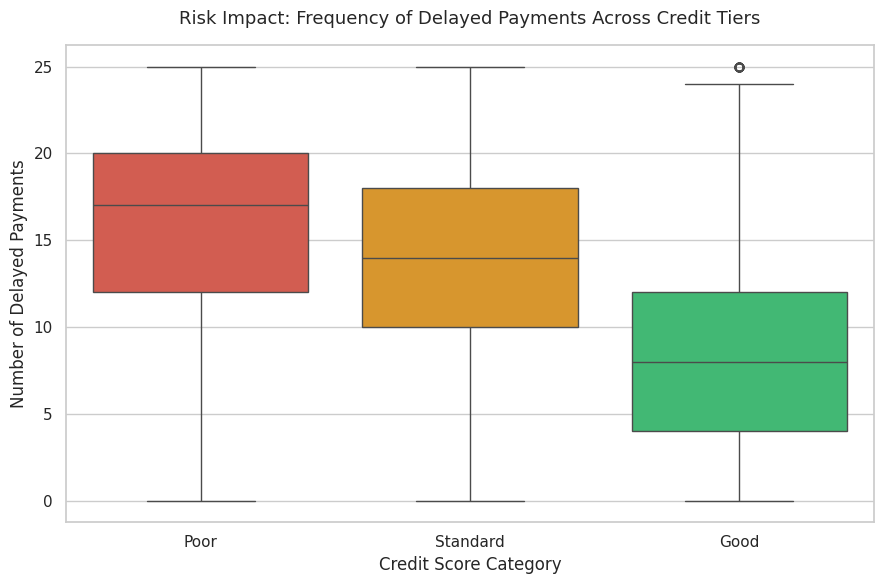

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=data, x='Credit_Score', y='Num_of_Delayed_Payment', hue='Credit_Score', legend=False,
    palette={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'})

plt.title('Risk Impact: Frequency of Delayed Payments Across Credit Tiers', fontsize=13, pad=15)
plt.xlabel('Credit Score Category')
plt.ylabel('Number of Delayed Payments')
plt.tight_layout()
plt.show()





#### **🔍 Observations:**

**Direct Step-Down Pattern:** There is a clear, progressive reduction in delayed payments across the credit tiers.

**The "Poor" Tier Distribution (Red):** This group exhibits the highest volume of Late payments, with a median of 17 delayed payments. The bulk of the data (IQR) is densely concentrated between 12 and 20 delayed payments.

**The "Standard" Tier Distribution (Yellow):** This group represents a transitional phase, holding a lower median of 14 delayed payments, with the distribution shifting downwards toward 10.

**The "Good" Tier Distribution (Green):** This premium tier demonstrates the most disciplined financial behavior. The median drops sharply to 8 delayed payments. The entire box sits significantly lower than the other two groups, with the bottom whisker reaching zero delayed payments.

**The High-Overdue accounts Anomaly:** There is a highly specific, solitary outlier point near 24 delayed payments sitting well above the upper whisker of the "Good" tier. This represents a rare anomaly: a customer who maintains a strong credit score despite an exceptionally high count of delayed payments.

#### **📊 Interpretations:**
there is a strong negative correlation between the number of delayed payments and credit scores.

In credit risk analytics, payment history is almost always the single most important factor determining a customer's risk profile. When a customer repeatedly delays monthly payments, it signals immediate cash flow issues or poor financial discipline, causing their credit score tier to drop.

#### **Implication**

Paisabazzar overlook this important metric to prevent risk because that the frequency of delayed payments is a highly sensitive and predictive indicator of overall credit worthiness.

Paisabazzar should set Critical Risk Boundaries that client with 15 delayed payments serves as a strong leading indicator that a customer's credit risk profile.

###**6. Anlysis of Distribution of credit scores across different age groups**

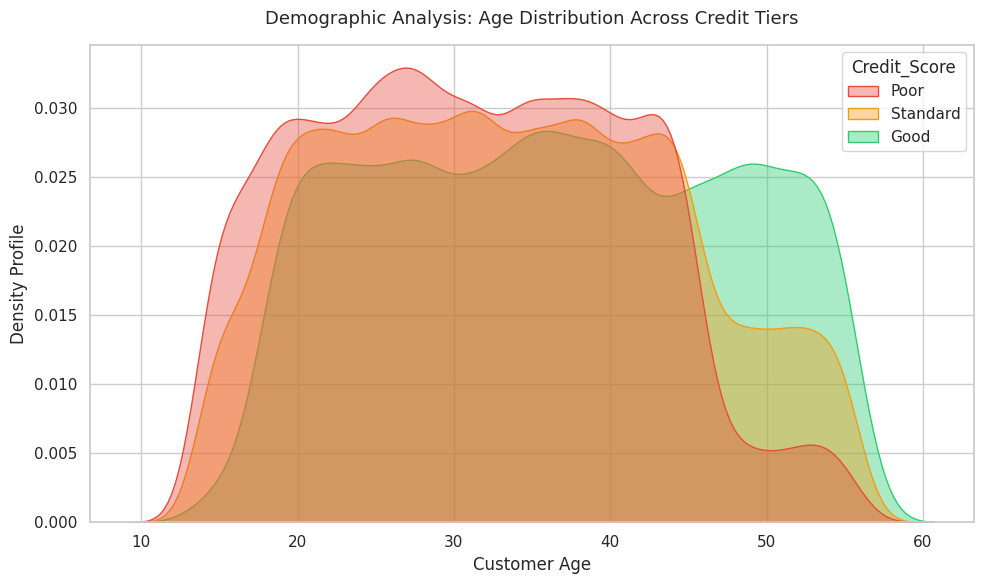

In [ ]:
plt.figure(figsize=(10, 6))

# Plotting age distributions using a kernel density estimate curve
sns.kdeplot(data=data, x='Age', hue='Credit_Score', fill=True, alpha=0.4, common_norm=False, palette={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'})

plt.title('Demographic Analysis: Age Distribution Across Credit Tiers', fontsize=13, pad=15)
plt.xlabel('Customer Age')
plt.ylabel('Density Profile')
plt.tight_layout()
plt.show()

#### **🔍 Observations**

**The Young Risk Group (Overlapping Red/Orange Peaks):**
Customers between the ages of 18 and 45 heavily dominate the "Poor" (red) and "Standard" (orange) categories. These two distributions almost perfectly overlap, peaking sharply around age 25 to 35.

**The Senior Group (Green Peak):** After age 45, the demographic story reverses completely. The density for "Poor" and "Standard" categories drop sharply toward zero. Simultaneously, the "Good" (green) distribution reaches its highest peak between the ages of 45 and 55.

**Hard Upper Boundary:**  All three distributions become gradually smaller, completely by age 60, reflecting the structural demographic limits of the active credit-seeking population in this dataset.

#### **📈 Interpretation**

This Kernel Density Estimate (KDE) plot visualizes the Demographic Age Distribution segmented by Credit Score Tiers (Poor, Standard, Good). It illustrates how consumer age correlates with credit health, revealing a distinct demographic shift where maturity aligns with significantly lower credit risk.

#### **⚠️ Paisabazzar's Strategic Risk Implications**

Paisabazzar should set a risk indicator that younger consumers carry significantly higher baseline credit risk. This is a common pattern in retail banking younger individuals typically have shorter credit histories, lower or less stable entry-level incomes, and higher initial debt-seeking behaviors (e.g., student or first-car loans).

Paisabazzar set more strategic offer and services to Age group of 45 and above.
Paisabazzar should confidently deploy pre-approved premium offers, higher credit limits, and lower interest rates, as the probability of an applicant falling into a "Poor" tier in this demographic is statistically minimal.



### **7. Analysis of trends or seasonal patterns in credit scores based on the month of years?**

In [ ]:
data['Month'].value_counts()

,count
Month,
1,12500
2,12500
3,12500
4,12500
5,12500
6,12500
7,12500
8,12500


In [ ]:
data['Month'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8])

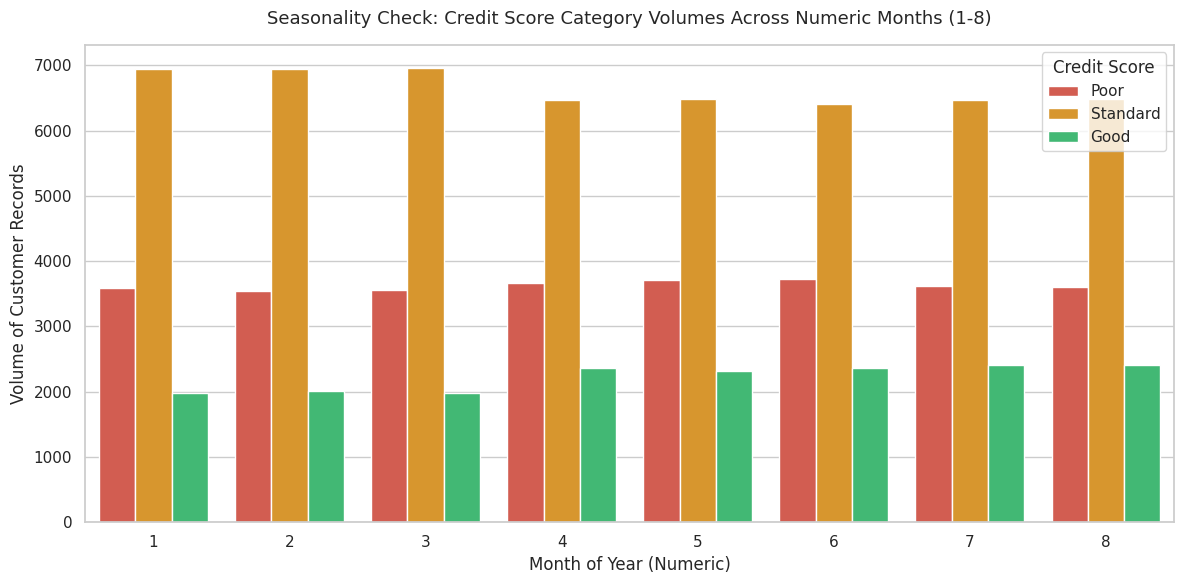

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Check and sort numeric months chronologically from 1 to 8
# Replace 'df' with your actual notebook DataFrame variable name
numeric_months = sorted(data['Month'].unique())

# Generate a grouped count plot over your actual numeric months
sns.countplot(data=data, x='Month', hue='Credit_Score', order=numeric_months, palette={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'})

plt.title('Seasonality Check: Credit Score Category Volumes Across Numeric Months (1-8)', fontsize=13, pad=15)
plt.xlabel('Month of Year (Numeric)')
plt.ylabel('Volume of Customer Records')
plt.legend(title='Credit Score')
plt.tight_layout()
plt.show()


#### **🔍 Observations**

**Dominant Category:** The "Standard" credit score category (orange bars) is consistently the largest volume across all 8 months, remaining high between 6000 and 7000 customer records.

**Lowest Category:** The "Good" credit score category (green bars) consistently represents the lowest volume of records, hovering around 2,000 to 2,500.

**Stable Patterns:** The volume for all three credit categories remains relatively flat and stable from Month 1 through Month 8.

#### **📈 Interpretations**

**Customer Base:** The primary customer base consists of individuals with average or "Standard" credit health, rather than highly risky ("Poor") or highly qualified ("Good") individuals.

**No Seasonality:** Seasonality factor have no significant impact by Credit Score because there are no significant spikes or dips across the numeric months, indicating that credit applications or records do not fluctuate based on the time of year.

#### **🚀 Implications:**

**Targeted Product Design:** PaisaBazar should make Business strategies, loan products, or marketing campaigns for "Standard" credit tier since they make up the vast majority of the volume.

**Risk management:** Steady data means teams can easily plan resources and budgets every month.

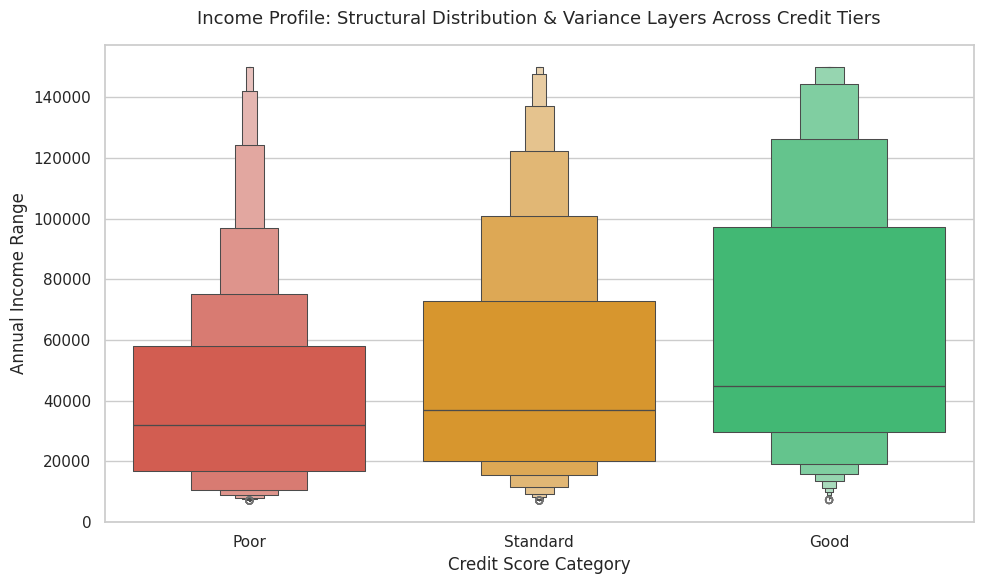

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxenplot(
    data=data,
    x='Credit_Score',
    y='Annual_Income',
    palette={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'},
    hue='Credit_Score',
    legend=False
)

plt.title('Income Profile: Structural Distribution & Variance Layers Across Credit Tiers', fontsize=13, pad=15)
plt.xlabel('Credit Score Category')
plt.ylabel('Annual Income Range')
plt.tight_layout()
plt.show()

####**🔍 Observations:**

**Higher income, better credit**: The Good credit group (green) sits much higher on the graph than the Poor group (red).

**Wide middle ranges:** Most people across all three groups earn between 30,000 and 100,000 .

**Top earners have good credit:** The very top of the green chart reaches up to 140,000, while the red chart thins out quickly at higher incomes.

####**📊 Interpretations:**

**Income drives credit score:** Higher income generally correlates with a better credit score.

**Income is not everything:** Some people with high incomes still have Poor credit, and some with lower incomes still manage Good credit.

####**🚀 Implications:**

**Tiered product offers:** Paisabazzar should Offer premium, high-limit Services to the Good credit tier since they have higher incomes.

**Targeted risk assessment:** For the Standard and Poor tiers, Paisabazzar should look closely at other factors (like debt or spending habits) also, not just their income, before approving them.

### **8. Analysing Multiple Variable Correlation with Credit Score**

In [ ]:

import numpy as np
import plotly.graph_objects as go

# 1. Mapping the Credit Score to sequential numbers for the matrix calculation
score_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
data['Credit_Score_Numeric'] = data['Credit_Score'].map(score_map)

# 2. Select the core financial and behavioral columns
corr_columns = ['Credit_Score_Numeric', 'Annual_Income', 'Age', 'Num_of_Delayed_Payment', 'Delay_from_due_date','Num_of_Loan', 'Num_Credit_Card', 'Credit_Utilization_Ratio','debt_to_income_ratio']

# Calculate the correlation matrix dataframe
corr_matrix = data[corr_columns].corr()

# 3. Generating the Interactive Plotly Heatmap
fig = go.Figure(data=go.Heatmap(z=corr_matrix.values, x=corr_matrix.columns, y=corr_matrix.index,
    colorscale='RdBu',  # Red for Positive, Blue for Negative
    reversescale=True,   # Keeps Red as Positive risk alignment, Blue as Negative impact
    zmin=-1,
    zmax=1,
    text=np.round(corr_matrix.values, 2),
    texttemplate="%{text}", # Displays the decimal values directly on top of the cells
    hoverongaps=False,
    hovertemplate="Feature 1: %{y}<br>Feature 2: %{x}<br>Correlation: %{z:.2f}<extra></extra>"
))

# Customizing layout for cleaner presentation
fig.update_layout(
    title={
        'text': "<b>Paisabazaar Correlation Matrix: Interactive Risk Driver Heatmap</b>",
        'y': 0.95, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    xaxis_title="Dataset Features",
    yaxis_title="Dataset Features",
    width=850,
    height=750,
    font=dict(family="Arial", size=12)
)

fig.show()


####**🔍 Observations:**

**1. Strong Positive Correlation:**

**Annual Income (+0.21):** This positive number proves that as income goes up, credit scores go up. Higher-earning individuals consistently move into better score brackets.

**Age (+0.16):** This shows that older customers generally have higher credit scores, likely because they have more financial experience and a longer credit file.

**2. Confirming the Flat Variable (0.05)**

Look at the intersection of Credit_Score_Numeric and Credit_Utilization_Ratio.

It shows a tiny, faint value of 0.05 (almost zero correlation).

This matches your very first boxplot discovery exactly, proving that how much credit limit a customer uses has almost no systematic impact on their credit rating in this specific dataset.


**3. Strong Negative Correlation**

**Delay from Due Date (-0.43):** This is the strongest negative driver in your entire dataset! Waiting too long past your bill deadline is the fastest way to drop down a risk tier.

**Number of Credit Cards (-0.40):** This confirms your earlier counter-intuitive discovery. In this specific data slice, owning too many credit cards actually hurts the profile.

**Num of Delayed Payments (-0.37) & Num of Loans (-0.35):** Having too many late flags or stacking up too many active loans heavily degrades a profile toward the "Poor" score class.

#### **📊 Interpretations:**

**Time Establishes Trust:** The positive traction with age proof of extended repayment behavior. A longer history gives the underlying algorithms more data points to verify consistent repayment habits

**Capacity Dictates Security:** Stronger annual income and multi-year employment lengths mean a borrower possesses a larger, more stable capital buffer to handle unexpected financial downturns.

**Leverage Amplifies Default Risk:** The heavy downward drag of high number of Due Delay, Multiple Credit Card and Delay from Due Date highlights a basic risk premium, mathematically pointing to a higher systemic probability of default.

#### **🚀 Implications:**

**High Income and Age Factor:** Paisabazzar should facilitate or give priorty to Offer premium , high-limit Services to Aged Client because Good credit tier since they have higher annual incomes.

**1. Pre-Approved Offers for High Earners:** Paisabazzar Automate "Instant Approval" journeys for high-income segments. Since Annual Income (+0.21) heavily drives top-tier credit brackets, these users require fewer verification friction points.

**2. Age-Tailored Secure Cards:** Paisabazzar should focus specifically for younger demographics. Since younger age correlates with lower scores due to short credit files, offer them secured cards backed by fixed deposits to safely establish history.

**Set Alternate other factor rather Credit Utilization for Approval:** Paisabazzar should Stop using high credit utilization as an automatic rejection trigger for loan matching. Since its correlation is flat (0.05).


# **Conclusion:**

Paisabazaar can reduce loan defaults and increase revenue by optimizing credit scoring, specifically by loosening rules for moderate card users, blocking customers with chronic late payments, high number of credit cards, multiple Loans and should targeting high-income earners and older Client with premium offers. The company should automate risk management to immediately block high-risk borrowers while expanding high-limit, pre-approved loan pipelines for individuals earning over $65,000.